# Dynamic-Graph Forecasting Analysis Hub

This notebook is the **single analysis entry point** for the final dynamic-graph forecasting models and their ablations. It does not train models and it does not silently generate missing predictions or graphs. Every result comes from an artefact that was saved by a separate training or inference notebook.

The notebook scans the user-managed directory:

```text
dissertation/models_to_use/
```

Every direct child folder is displayed. There is no whitelist of permitted folder names. A new ablation can be added simply by copying its frozen run folder into `models_to_use` and supplying that exact folder name in a later function call.

## Data-split contract

Every saved-artefact analysis accepts:

```text
split="train"
split="validation"   # "val" is also accepted
split="test"
```

`split="train"` means the **final selected checkpoint evaluated over training windows**. It does not mean an intermediate training epoch. The graph loader verifies that a training-split graph artefact records the run's selected checkpoint epoch. If an artefact does not exist, the notebook raises a clear error and stops that cell; it never launches inference itself.

## Tokenized inference policy

For a continuous model, `policy=None` is ignored because there is no sampling policy. For a tokenized model, `policy=None` reads the selected temperature from the saved temperature-selection manifest. If several policies exist and no unique selected policy can be identified, the function raises and lists the available policy folders. An explicit value such as `policy="temperature_1"` always overrides automatic selection.

## Graph orientation

All graph functions use the canonical project convention:

$$
A_{ij}=A[\text{target }i,\text{ source }j].
$$

Rows are receiving assets and columns are influencing assets. Spatial message passing is therefore:

$$
m_i=\sum_j A_{ij}v_j.
$$

The adjacency is the routing matrix used by the model. It is not, by itself, evidence that a financial relationship is causal.

In [1]:
# Imports only. There are deliberately no model presets in this setup cell.
from pathlib import Path
import importlib
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.evaluation.dynamic_graph_evaluation as dge

dge = importlib.reload(dge)

print("Project root:", project_root)
print("Models root:", dge.resolve_models_to_use_root())
print("Evaluation module:", dge.__file__)
print("Evaluation module version:", dge.EVALUATION_MODULE_VERSION)


Project root: /Users/vishalruparelia/Desktop/Thesis/dynamic_graphs_thesis
Models root: /Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/models_to_use
Evaluation module: /Users/vishalruparelia/Desktop/Thesis/dynamic_graphs_thesis/src/evaluation/dynamic_graph_evaluation.py
Evaluation module version: 2026-08-05-v11-final-graph-hub


## 1. Discover every model folder

This is a directory inventory, not a model-selection rule. The function lists **every direct child directory** under `models_to_use`, including folders whose files are incomplete or whose schema is not recognised. The `Issue` column explains why a folder could not be read.

The availability columns indicate whether at least one saved artefact can be found for each split. They do not imply that all required artefacts exist. For example, a training folder may contain a graph but no prediction metric table, which is sufficient for training-period graph analysis but not for forecast-metric comparison.

In [12]:
# Input:
# - models_root=None: auto-detect the Mac or Colab models_to_use directory.
#   Pass an explicit path to inspect another folder.
model_inventory = dge.discover_models(models_root=None)

display(
    dge.style_numeric_table(
        model_inventory,
        caption="Every folder currently present in models_to_use",
        precision=4,
    )
)


,Folder,Path,Run metadata,Resolved config,History,Best checkpoint,Last checkpoint,Saved train analysis,Saved validation analysis,Saved test analysis,Family,Status,Graph type,Issue
0,continuous_dynamic,/Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/models_to_use/continuous_dynamic,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,continuous,completed,dynamic,—
1,continuous_dynamic_sector_state,/Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/models_to_use/continuous_dynamic_sector_state,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,continuous,completed,static_dynamic_mixture,—
2,mid_alpha_mid_beta_correl_exp_weighted,/Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/models_to_use/mid_alpha_mid_beta_correl_exp_weighted,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,continuous,completed,static_dynamic_mixture,—
3,stacked_dynamic,/Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/models_to_use/stacked_dynamic,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,continuous,completed,dynamic,—
4,tokenized_basedygraph,/Users/vishalruparelia/Library/CloudStorage/GoogleDrive-vishal@autonomous-fox.ai/My Drive/dissertation/models_to_use/tokenized_basedygraph,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,token,completed,dynamic,—


## 2. Audit the saved artefacts used in a comparison

The discovery table above is intentionally broad. This audit is the stricter check applied to the exact models you plan to compare in one table or figure.

For each supplied folder, the audit reports whether it has saved predictions, graphs, common evaluator metrics, sampled price paths and sampled token artefacts for the requested split. The audit loads the saved prediction bundle first because its window metadata is used to align graph tensors, dates, origins and metrics. A complete canonical split bundle therefore contains predictions and may additionally contain graphs, metrics, sampled paths and token artefacts. Training-split bundles must record the checkpoint epoch so Graph Hub can verify that they were generated from the run's final selected checkpoint.

The mapping below is user-editable. Add or remove any model folder; the names are not built into the evaluation code.

In [13]:
# Inputs:
# - models: display label -> exact folder name under models_to_use, or direct path.
# - split: "train", "validation"/"val", or "test".
# - policies: optional display label -> token policy. Use None to read the saved
#   selected temperature; continuous models ignore policy.
artifact_audit = dge.make_model_artifact_audit(
    {
        "Continuous dynamic": "continuous_dynamic",
        "Tokenized BaseDyGraph": "tokenized_basedygraph",
        "Continuous dynamic sector state": "continuous_dynamic_sector_state",
        "Mid Alpha Mid Beta Exp Weighted": "mid_alpha_mid_beta_correl_exp_weighted",
        "Stacked_dynamic": "stacked_dynamic"
    },
    split="validation",
    policies={
        "Tokenized dynamic": None,
    },
)

display(
    dge.style_model_artifact_audit(
        artifact_audit,
        caption="Saved artefact audit for the requested model comparison",
    )
)


,Model,Folder,Family,Split,Policy,Graph type,Windows,Horizons,Assets,Predictions,Graphs,Metrics,Sampled paths,Temperature,Sample count,Ready,Issue
0,Continuous dynamic,continuous_dynamic,continuous,validation,best,dynamic,380,"(1, 5, 15, 30, 60)",93,True,True,True,False,—,—,True,—
1,Tokenized BaseDyGraph,tokenized_basedygraph,token,validation,temperature_1,dynamic,380,"(1,)",93,True,True,True,True,1.000,10,True,—
2,Continuous dynamic sector state,continuous_dynamic_sector_state,continuous,validation,best,static_dynamic_mixture,380,"(1, 5, 15, 30, 60)",93,True,True,True,False,—,—,True,—
3,Mid Alpha Mid Beta Exp Weighted,mid_alpha_mid_beta_correl_exp_weighted,continuous,validation,best,static_dynamic_mixture,380,"(1, 5, 15, 30, 60)",93,True,True,True,False,—,—,True,—
4,Stacked_dynamic,stacked_dynamic,continuous,validation,best,dynamic,380,"(1, 5, 15, 30, 60)",93,True,True,True,False,—,—,True,—


## 3. Inspect the exact saved architecture

Run-directory names are abbreviations and should not be used as the source of truth. This table reads each model's own `resolved_config.json` and `run_metadata.json` and places the saved architecture, graph configuration, optimisation settings and checkpoint provenance side by side.

Use this table when writing the methods and ablation sections. A claimed one-factor ablation should differ only in the intended setting; any additional difference visible here is a confound that must be reported.

In [232]:
# Input:
# - arbitrary display label -> model folder mapping. Add or remove folders freely.
architecture_table = dge.make_model_architecture_comparison(
    {
       "Tokenized BaseDyGraph": "tokenized_basedygraph",
    }
)

display(
    dge.style_numeric_table(
        architecture_table,
        caption="Exact architecture and optimisation settings read from saved configs",
    )
)


,Tokenized BaseDyGraph
Field,
Run family,token
Run name,tokenized_basedygraph
Assets,93
Evaluation horizons,"[1, 5, 15, 30, 60]"
Selection metric,mean_top1_accuracy_over_all_future_steps
Token input representation,coarse_s1_embedding
Temporal backbone,modern_tcn_transformer
Hidden dimension,96
ModernTCN blocks,—


## 4. Training history: objective, graph concentration and spatial gate

This section reads `history.csv`; it never reruns a model. Three concepts are intentionally plotted on separate scales.

### Predictive objective

The first figure shows the run's training and validation objective. Continuous models usually optimise cumulative-log-change error, whereas token models optimise coarse-token cross-entropy. Their absolute values are not comparable across model families.

### Graph concentration

For a row-stochastic graph row $A_i$:

$$
H_i=-\sum_j A_{ij}\log A_{ij}.
$$

The effective number of neighbours is:

$$
n_{\mathrm{eff},i}=\exp(H_i).
$$

Lower entropy and fewer effective neighbours mean that incoming graph weight is concentrated on a smaller set of source assets. This is not automatically better: concentration should be interpreted together with forecast performance and graph interventions.

### Learned spatial gate

The learned gate is plotted in a separate figure because it has a different meaning and scale. For the continuous graph model:

$$
H_{\mathrm{fused}}=(1-\beta)H_{\mathrm{temporal}}+\beta H_{\mathrm{graph}}.
$$

A larger $\beta$ means greater exposure to the graph-aware branch. It does **not** mean that the adjacency itself is more concentrated.

In [ ]:
# Input:
# - model: exact model folder name or direct path.
training_report = dge.analyse_training_history(
    "official_basedygraph",
)

plt.show()

display(
    dge.style_numeric_table(
        training_report.history.tail(20),
        caption="Final 20 recorded epochs",
        precision=6,
    )
)


## 5. Common point-forecast metrics

All models in this table are read from saved common-evaluator metric files. The horizon rows correspond to cumulative changes from the final observed Close to 1, 5, 15, 30 and 60 minutes ahead.

- **Log MAE**: mean absolute error in cumulative log-return space. Lower is better and values are comparable across assets with different price levels.
- **Log MedAE**: median absolute cumulative-log-return error. It describes a typical forecast and is less sensitive to large misses.
- **Log P95 AE**: 95th percentile absolute cumulative-log-return error. It describes the error tail; lower is better.
- **MASE**: raw-price MAE divided by a fixed training-derived scale. It is standardised but is not a horizon-matched persistence ratio.
- **Rel. MAE**: the existing raw-price model MAE divided by raw-price persistence MAE. Below one beats persistence in that metric. It is not the ratio of the Log MAE columns.
- **Win Rate**: fraction of individual forecasts with lower raw absolute error than persistence; ties contribute 0.5.
- **Pearson**: pooled signed correlation between predicted and realised cumulative log returns across windows and assets.
- **IC**: cross-sectional Pearson correlation across assets at each forecast origin, averaged over origins.
- **Rank IC**: cross-sectional Spearman correlation. It evaluates ordering while reducing sensitivity to magnitude calibration.
- **MMR**: predicted movement magnitude divided by realised movement magnitude. Values below one indicate under-dispersion and values above one indicate excessive movement.
- **AbsRet Corr**: temporal correlation between predicted and realised absolute cumulative returns. It tests whether high-volatility periods are identified even when sign is wrong.

The function accepts train, validation or test metric bundles. Missing files cause a clear error rather than an inference run.

In [ ]:
# Inputs:
# - models: any label -> model folder mapping.
# - split: "train", "validation"/"val", or "test".
# - policies: tokenized policy per label; None reads its saved selected policy.
metric_comparison = dge.make_model_metric_comparison(
    {
        "Continuous dynamic": "continuous_dynamic",
        "Continuous dynamic sector state": "continuous_dynamic_sector_state",
        "Mid Alpha Mid Beta Exp Weighted": "mid_alpha_mid_beta_correl_exp_weighted",
    },
    split="test",
    policies={"Tokenized dynamic": None},
    metrics_to_display=(
        "cumulative_log_change_mae",
        #"cumulative_log_change_median_absolute_error",
        #"cumulative_log_change_p95_absolute_error",
        #"mase",
        "relative_mae_vs_persistence",
        "persistence_win_rate",
        "cumulative_log_change_pearson_correlation",
        "cumulative_log_change_cross_sectional_pearson_ic",
        "cumulative_log_change_cross_sectional_spearman_rank_ic",
        "cumulative_log_change_movement_magnitude_ratio",
        "cumulative_log_change_temporal_absolute_correlation",
    ),
)

display(
    dge.style_model_metric_comparison(
        metric_comparison,
        caption="Common saved forecast metrics",
    )
)


## 6. Point forecasts for one exact or random example

This plot overlays saved model forecasts against the same realised future for one asset and one forecast window.

Random selection is explicit and reproducible:

```text
asset="random"
day="random"
window="random"
random_seed=42
```

For this point-forecast plot, `None` is not used because averaging raw prices across unrelated assets or windows would not produce an interpretable path. Supply an exact ticker/date/one-based window, or use the explicit `"random"` sentinel.

The plotted values are raw Close prices. Use the accompanying table to inspect errors at each reported horizon.

In [ ]:
# Inputs:
# - models: models to overlay; they must share the same split/window contract.
# - split: "train", "validation"/"val", or "test".
# - policies: tokenized policy; None reads the saved selected temperature.
# - asset: ticker, zero-based index, or "random".
# - day/window: exact date and one-based window, or "random".
# - random_seed: makes random choices reproducible.
point_report = dge.plot_point_forecast_example(
    {
        "Continuous dynamic": "continuous_dynamic",
        "Tokenized dynamic": "tokenized_dynamic",
    },
    split="val",
    policies={"Tokenized dynamic": None},
    asset="random",
    day="random",
    window="random",
    random_seed=np.random.randint(0,1e6),
)

plt.show()

display(
    dge.style_numeric_table(
        point_report.values,
        caption="Point forecasts and realised values for the selected example",
        precision=6,
    )
)


## 7. Generic adjacency analysis

This is the single adjacency section for dynamic, static, correlation and tokenized models. Change the model folder and split in the function call rather than duplicating the section.

### Date/window selection

The `day` and `window` arguments have a fixed convention:

| `day` | `window` | Result |
|---|---|---|
| exact date | exact positive integer | one exact saved graph |
| exact date | `None` | average all forecast windows on that date |
| `None` | exact positive integer | average that within-day window over every available date |
| `None` | `None` | average every graph in the selected split |
| `"random"` | `"random"` | one reproducibly random exact graph |

`None` always means averaging. It never means random selection.

### Clustering

`cluster=False` is the default. This preserves the same ticker order across days and windows, which is necessary for visual comparison. Set `cluster=True` only when the purpose is to reveal block structure within a single matrix; clustered matrices from different windows may use different row/column orders.

### Outputs

The function returns:

1. the actual row-stochastic adjacency heatmap;
2. a concentration/provenance summary;
3. the strongest incoming or outgoing connections;
4. a top-$N$ influence-count table and bar chart.

For the influence count, each target asset contributes its $N$ strongest **non-self** source assets. The count for source $j$ is:

$$
C_j=\sum_{i\neq j}\mathbf{1}\left[j\in\operatorname{TopN}(A_{i,:})\right].
$$

With 93 assets, the maximum is 92 because self influence is excluded. A count of 92 means that the source appears among the top-$N$ influencers of every other asset.

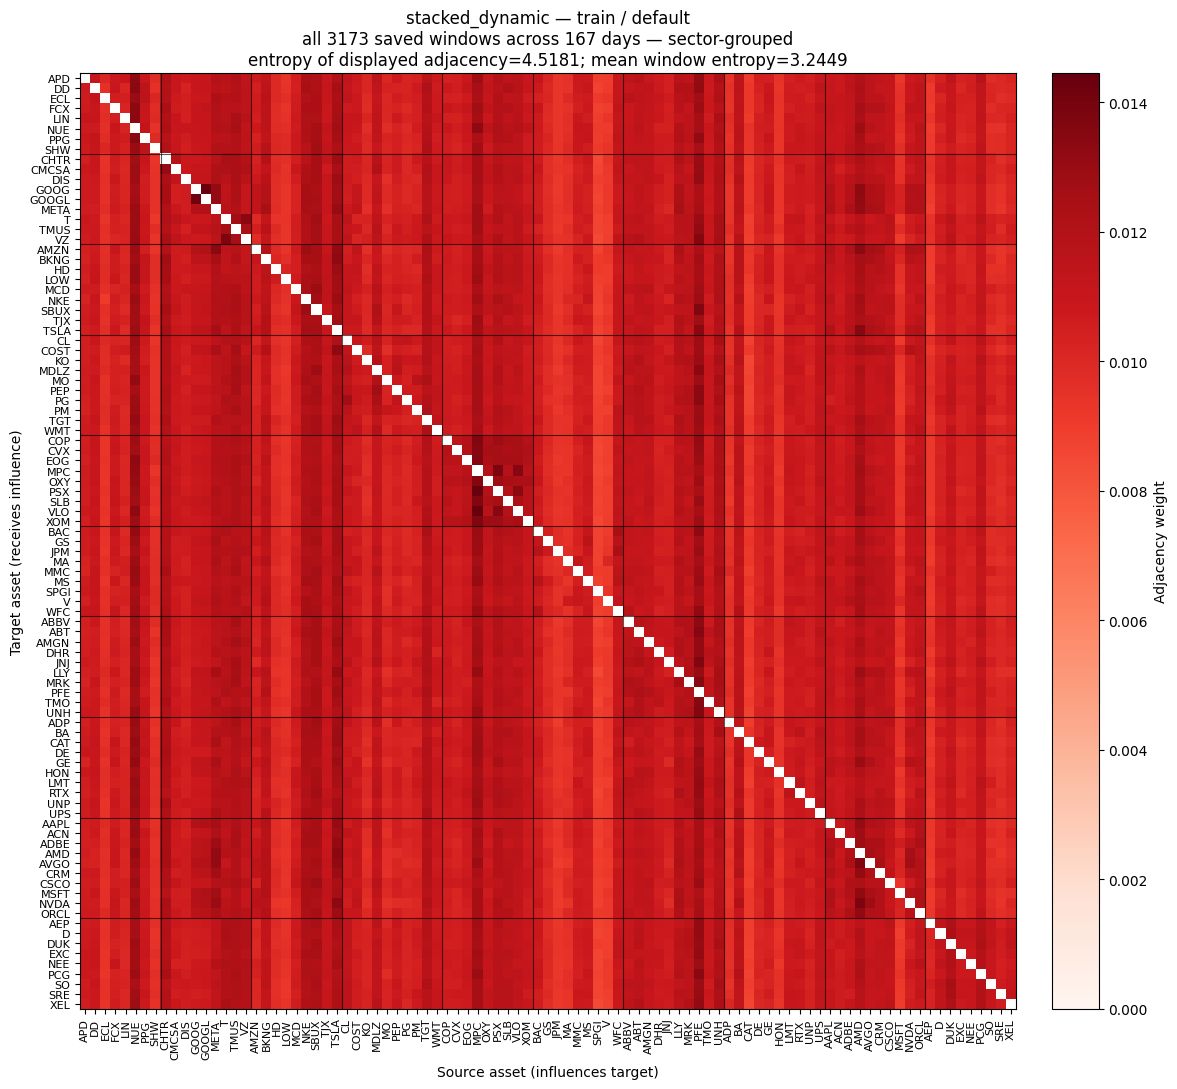

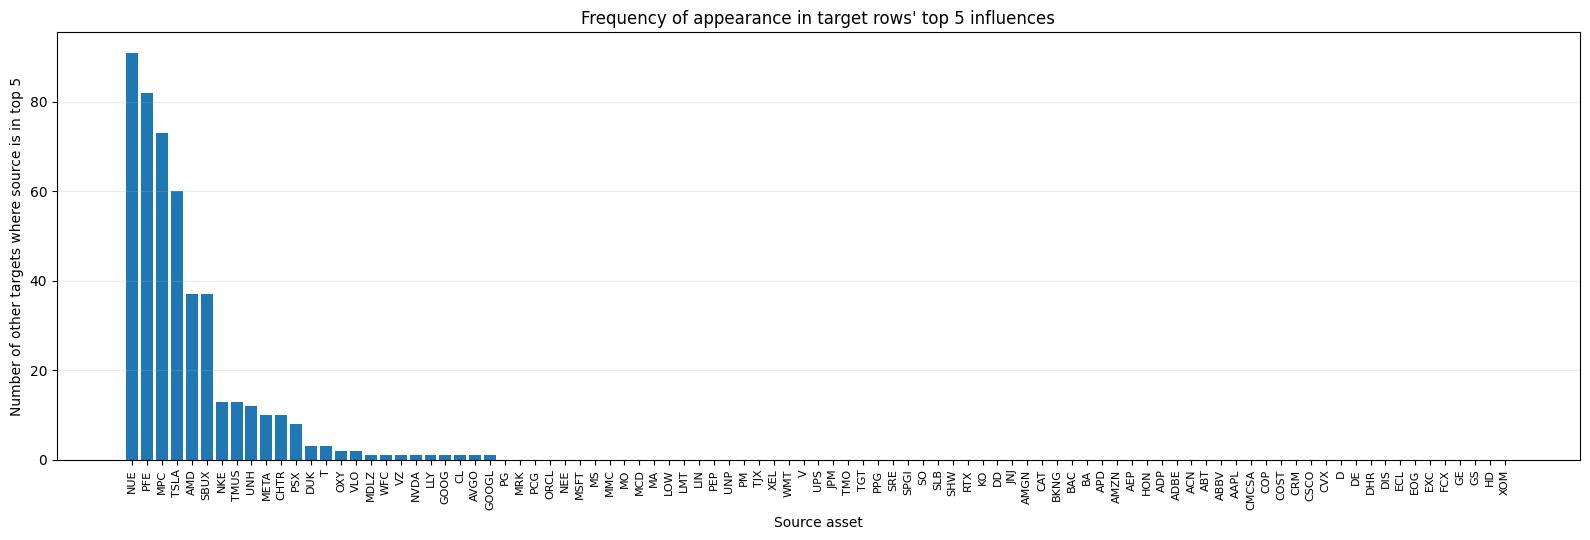

,Run,Family,Split,Policy,Graph type,Component,Layer,Head,Selection,Clock-time window,Selected windows,Entropy of displayed mean adjacency,Effective neighbours of displayed mean adjacency,Mean window-specific row entropy,Mean window-specific effective neighbours,Maximum displayed edge weight,Mean displayed top-5 row mass
0,stacked_dynamic,continuous,train,default,dynamic,selected,2.00000,mean,all 3173 saved windows across 167 days,—,3173.00000,4.51812,91.66295,3.24493,30.28199,0.01445,0.06383


,Neighbour 1,Weight 1,Neighbour 2,Weight 2,Neighbour 3,Weight 3,Neighbour 4,Weight 4,Neighbour 5,Weight 5
Stock,,,,,,,,,,
AAPL,TSLA,0.013057,AMD,0.013039,NUE,0.012884,PFE,0.012601,META,0.012578
ABBV,PFE,0.013224,NUE,0.012727,SBUX,0.012589,TMUS,0.012517,CHTR,0.012456
ABT,PFE,0.013527,NUE,0.012601,SBUX,0.012484,MPC,0.012433,CHTR,0.012383
ACN,NUE,0.012947,TSLA,0.012818,AMD,0.012766,MPC,0.012684,SBUX,0.012532
ADBE,TSLA,0.013105,AMD,0.012867,META,0.012772,NUE,0.012684,NKE,0.012585
ADP,NUE,0.012972,SBUX,0.012726,TSLA,0.012680,PFE,0.012558,MPC,0.012460
AEP,PFE,0.013133,MPC,0.012651,NUE,0.012611,SBUX,0.012393,TSLA,0.012370
AMD,TSLA,0.013332,META,0.013132,NUE,0.013071,PFE,0.012740,NVDA,0.012598
AMGN,PFE,0.013131,TSLA,0.012856,NUE,0.012827,TMUS,0.012633,MPC,0.012553


,Source asset,Targets for which source is in top 5,Eligible target assets,Proportion of eligible targets
0,NUE,91.000,92.000,0.989
1,PFE,82.000,92.000,0.891
2,MPC,73.000,92.000,0.793
3,TSLA,60.000,92.000,0.652
4,AMD,37.000,92.000,0.402
5,SBUX,37.000,92.000,0.402
6,NKE,13.000,92.000,0.141
7,TMUS,13.000,92.000,0.141
8,UNH,12.000,92.000,0.130
9,CHTR,10.000,92.000,0.109


In [17]:
# Inputs:
# - model: any exact folder under models_to_use, or a direct path.
# - split: "train", "validation"/"val", or "test".
# - policy: None reads a token model's selected saved policy; continuous ignores it.
# - day/window: exact, None for averaging, or "random" as documented above.
# - component: "selected", "base", or "dynamic" when saved.
# - layer: -1 uses the selected graph; another integer selects a saved ST layer.
# - head: "mean" averages graph heads, or pass a zero-based head index.
# - top_n: number of non-self connections shown and counted.
# - direction: "impacted_by" lists sources per target; "impacts" reverses the view.
# - cluster: keep False for window-to-window comparison.
graph_report = dge.analyse_graph(
    "stacked_dynamic",
    split="train",
    policy=None,
    day=None,
    window=None,
    component="selected",
    layer=2,
    head="mean",
    top_n=5,
    direction="impacted_by",
    cluster=True,
    random_seed=np.random.randint(0,1e6),
    heatmap_cap_top_k=0
)

plt.show()

display(dge.style_numeric_table(graph_report.summary, caption="Graph selection and concentration summary", precision=5))
display(dge.style_numeric_table(graph_report.connections, caption="Strongest graph connections", precision=6))
display(dge.style_numeric_table(graph_report.top_source_frequency, caption="How often each asset appears in other assets' top-5 sources", precision=3))


## 8. How dynamic-graph entropy varies across days and assets

A single mean entropy hides whether the graph is consistently diffuse or changes substantially with market conditions. This section calculates row entropy on the **unaveraged graph for every selected forecast window**.

### Daily calculation

For day $d$, with forecast windows $w$ and receiving assets $i$, the daily statistic is:

$$
\overline H_d=\frac{1}{|W_d|N}\sum_{w\in W_d}\sum_{i=1}^{N}H(A_{d,w,i,:}).
$$

The daily table reports $\overline H_d$ for every date. The summary then reports the mean, lower quartile and upper quartile of those daily values across the split, together with the highest- and lowest-entropy dates. The line plot shows $\overline H_d$ through time; the x-axis labels only the first saved day of each month using the abbreviated month name.

If graph entropy rises during unusually volatile periods, the dynamic graph is spreading incoming weight over more assets. If it falls, the model is concentrating on a smaller set of sources. This is a descriptive association, not proof that volatility caused the graph change.

### Asset calculation

For each receiving asset $i$, the table reports the mean, lower quartile and upper quartile of its row entropy across selected windows. This identifies assets whose incoming dependency pattern is persistently broad versus consistently selective.

The same `day`/`window` convention from the adjacency section applies. For a full-split study, use both as `None`. To study the first window of every day, use `day=None, window=1`.

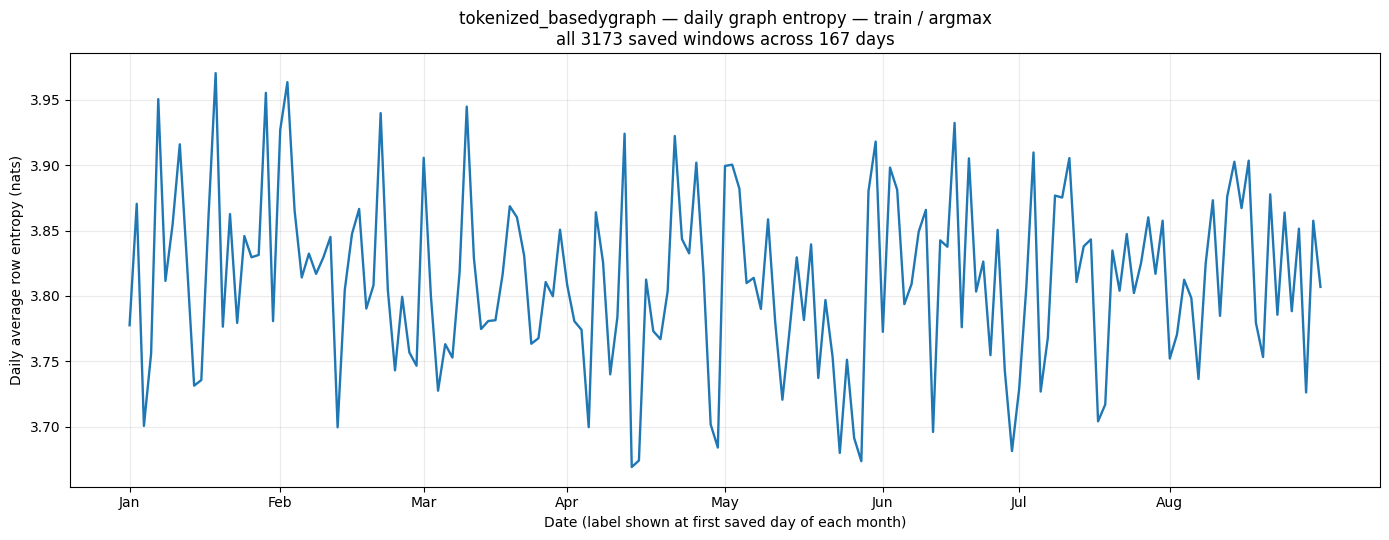

,Selected split,Selection,Days,Mean of daily average row entropy,Lower quartile of daily average row entropy,Upper quartile of daily average row entropy,Lowest-entropy day,Lowest daily average row entropy,Highest-entropy day,Highest daily average row entropy
0,train,all 3173 saved windows across 167 days,167.00000,3.81321,3.77284,3.85939,2024-04-12,3.66917,2024-01-19,3.97047


,Date,Windows,Daily mean row entropy
0,2024-01-02,19.00000,3.77761
1,2024-01-03,19.00000,3.87050
2,2024-01-04,19.00000,3.70060
3,2024-01-05,19.00000,3.75586
4,2024-01-08,19.00000,3.95058
5,2024-01-09,19.00000,3.81153
6,2024-01-10,19.00000,3.85480
7,2024-01-11,19.00000,3.91603
8,2024-01-12,19.00000,3.82545
9,2024-01-16,19.00000,3.73139


In [227]:
# Inputs:
# - model/split/policy/component/layer/head: same meanings as the adjacency cell.
# - day/window: None means aggregate the corresponding dimension; "random" is
#   allowed but is usually not useful for a split-wide entropy study.
entropy_report = dge.analyse_graph_entropy(
    "tokenized_basedygraph",
    split="train",
    policy=None,
    day=None,
    window=None,
    component="selected",
    layer=2,
    head="mean",
    random_seed=30
)

plt.show()

display(dge.style_numeric_table(entropy_report.day_summary, caption="Distribution of daily average row entropy", precision=5))
display(dge.style_numeric_table(entropy_report.day_values, caption="Average row entropy on every day in the selected split", precision=5))
#display(dge.style_numeric_table(entropy_report.asset_summary, caption="Row-entropy distribution by receiving asset", precision=5))


## 9. Convert the company graph into sector graphs

The company-profile file maps each of the 93 project tickers to one of 10 sectors. The function validates that every model asset has exactly one sector before aggregation.

### Sector-to-sector graph

Let $s(i)$ be the sector of target asset $i$ and $s(j)$ the sector of source asset $j$. The unnormalised sector weight is:

$$
S_{uv}=\sum_{i:s(i)=u}\sum_{j:s(j)=v}A_{ij}.
$$

The sector graph is then row-normalised:

$$
\widetilde S_{uv}=\frac{S_{uv}}{\sum_{v'}S_{uv'}}.
$$

Row $u$ therefore answers: **from which source sectors does target sector $u$ receive graph weight?**

### Asset-to-sector graph

For target asset $i$ and source sector $v$:

$$
G_{iv}=\sum_{j:s(j)=v}A_{ij}.
$$

Each row sums to one. The heatmap shows, at a glance, how much each asset is influenced by each sector. Target assets are ordered first by their own sector and then alphabetically. A sector strip and group labels on the left make the row grouping explicit.

Both graphs use the same exact/averaged/random date and window selection as the company-level adjacency.

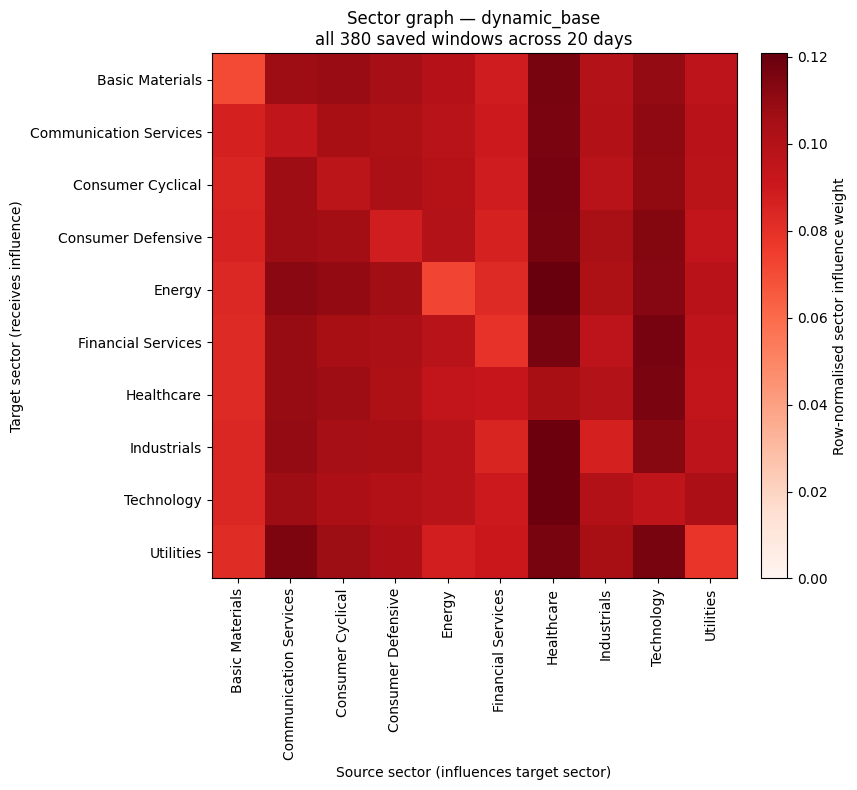

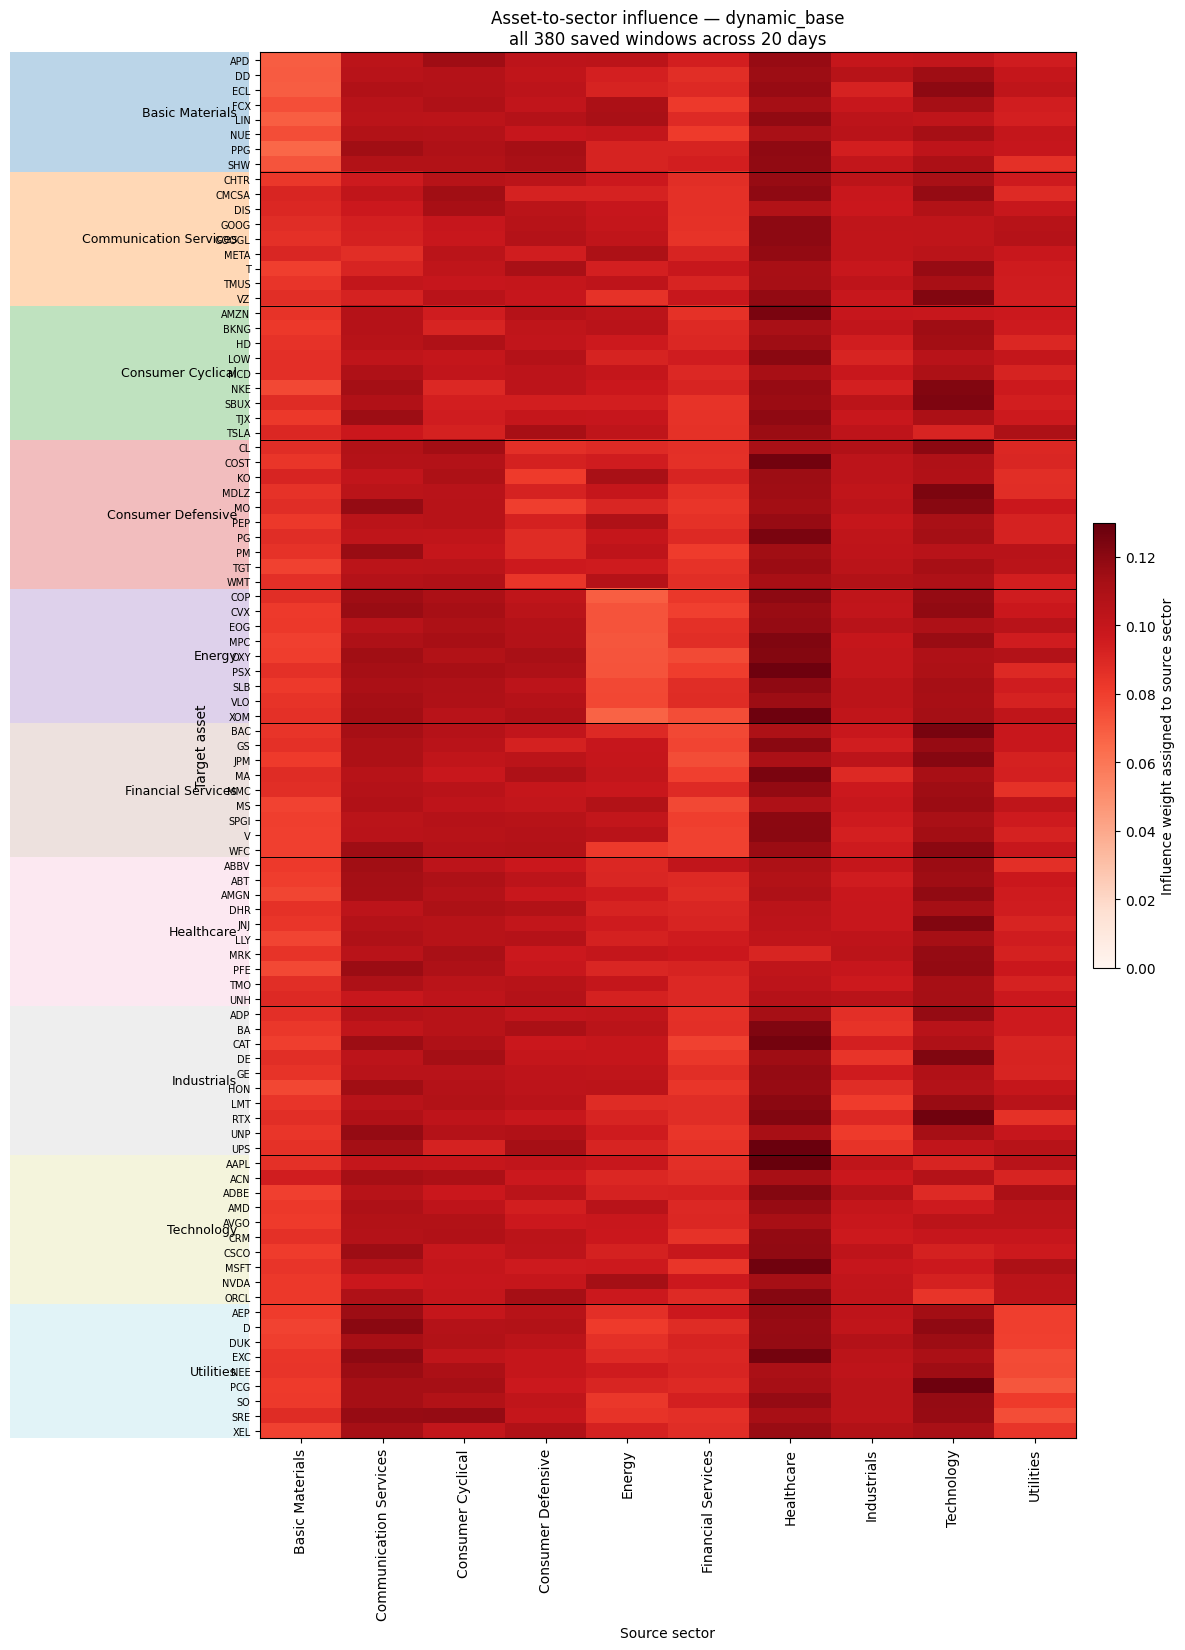

,Sector,Assets
0,Basic Materials,8
1,Communication Services,9
2,Consumer Cyclical,9
3,Consumer Defensive,10
4,Energy,9
5,Financial Services,9
6,Healthcare,10
7,Industrials,10
8,Technology,10
9,Utilities,9


,Run,Family,Split,Policy,Graph type,Component,Layer,Head,Selection,Clock-time window,Selected windows,Entropy of displayed mean adjacency,Effective neighbours of displayed mean adjacency,Mean window-specific row entropy,Mean window-specific effective neighbours,Maximum displayed edge weight,Mean displayed top-5 row mass
0,dynamic_base,continuous,validation,best,dynamic_base,selected,-1.00000,mean,all 380 saved windows across 20 days,—,380.00000,4.50376,90.35629,3.92229,52.97427,0.02070,0.07913


Source sector,Basic Materials,Communication Services,Consumer Cyclical,Consumer Defensive,Energy,Financial Services,Healthcare,Industrials,Technology,Utilities
Target sector,,,,,,,,,,
Basic Materials,0.07046,0.10701,0.10811,0.10493,0.09940,0.08844,0.11616,0.09986,0.10942,0.09621
Communication Services,0.08654,0.09479,0.10435,0.10196,0.09798,0.08986,0.11577,0.10051,0.11064,0.09761
Consumer Cyclical,0.08457,0.10702,0.09643,0.10316,0.09892,0.08834,0.11672,0.09799,0.10995,0.09690
Consumer Defensive,0.08549,0.10701,0.10614,0.08818,0.09975,0.08595,0.11640,0.10359,0.11329,0.09420
Energy,0.08331,0.11226,0.10962,0.10648,0.07244,0.08242,0.12080,0.10208,0.11305,0.09754
Financial Services,0.08253,0.10856,0.10405,0.10311,0.09800,0.07892,0.11654,0.09622,0.11681,0.09526
Healthcare,0.08228,0.10877,0.10682,0.10221,0.09400,0.09243,0.10390,0.09968,0.11578,0.09413
Industrials,0.08375,0.10908,0.10551,0.10399,0.09783,0.08478,0.11937,0.08676,0.11269,0.09624
Technology,0.08393,0.10708,0.10240,0.10096,0.09813,0.08984,0.11899,0.10057,0.09528,0.10282


Source sector,Basic Materials,Communication Services,Consumer Cyclical,Consumer Defensive,Energy,Financial Services,Healthcare,Industrials,Technology,Utilities
Target asset,,,,,,,,,,
APD,0.06921,0.10354,0.11461,0.10321,0.10352,0.09381,0.11663,0.09946,0.10085,0.09516
DD,0.06994,0.10526,0.10693,0.10187,0.09376,0.08706,0.11517,0.10553,0.11503,0.09945
ECL,0.06906,0.10834,0.10726,0.10320,0.09198,0.08914,0.11701,0.09239,0.11930,0.10231
FCX,0.07423,0.10528,0.10856,0.10097,0.11040,0.08195,0.11295,0.09876,0.11257,0.09432
LIN,0.06855,0.10429,0.10360,0.10687,0.11113,0.08832,0.11849,0.10311,0.10202,0.09360
NUE,0.07492,0.10779,0.10727,0.09925,0.10054,0.08130,0.11135,0.10484,0.11266,0.10007
PPG,0.06547,0.11407,0.10882,0.11288,0.09197,0.09201,0.11909,0.09424,0.10257,0.09888
SHW,0.07229,0.10754,0.10785,0.11115,0.09190,0.09392,0.11857,0.10053,0.11035,0.08589
CHTR,0.08300,0.09620,0.10556,0.10382,0.09714,0.08700,0.11679,0.10345,0.11113,0.09591


In [10]:
# Inputs:
# - model/split/policy/day/window/component/layer/head: same graph selectors as above.
# - company_profiles_path=None: auto-detect dissertation/company_profiles.csv
#   on Mac or Colab; pass an explicit path to override.
sector_report = dge.analyse_sector_graph(
    "dynamic_base",
    split="val",
    policy=None,
    day=None,
    window=None,
    component="selected",
    layer=-1,
    head="mean",
    company_profiles_path=None,
    random_seed=42
)

plt.show()

sector_counts = (
    sector_report.asset_sector_mapping
    .groupby("Sector", as_index=False)
    .agg(Assets=("Ticker", "count"))
)
display(sector_counts)
display(
    dge.style_numeric_table(
        dge.make_selected_graph_summary(sector_report.graph),
        caption="Graph selection used for sector aggregation",
        precision=5,
    )
)
display(
    dge.style_numeric_table(
        sector_report.sector_adjacency,
        caption="Row-normalised sector-to-sector graph",
        precision=5,
    )
)
display(
    dge.style_numeric_table(
        sector_report.asset_sector_adjacency,
        caption="Asset-to-source-sector graph",
        precision=5,
    )
)


## 10. Inspect the tokenized model's sampled price paths

This plot is the most direct view of the predictive distribution. Each thin line is one complete decoded future Close path. The thick ensemble-mean line is the point forecast used for the sampled model's common metrics. The realised future path is shown when the canonical candle data are available.

Random selection again uses the explicit `"random"` sentinel for asset, day and window. To reproduce a write-up figure, replace them with an exact ticker, date and one-based window.

A useful failure pattern is a tight bundle of paths that consistently misses the realised path. That indicates **under-dispersion**: sampling produces too little uncertainty around a biased centre. A very wide bundle that often contains truth may have reasonable coverage but poor sharpness and weak point forecasts.

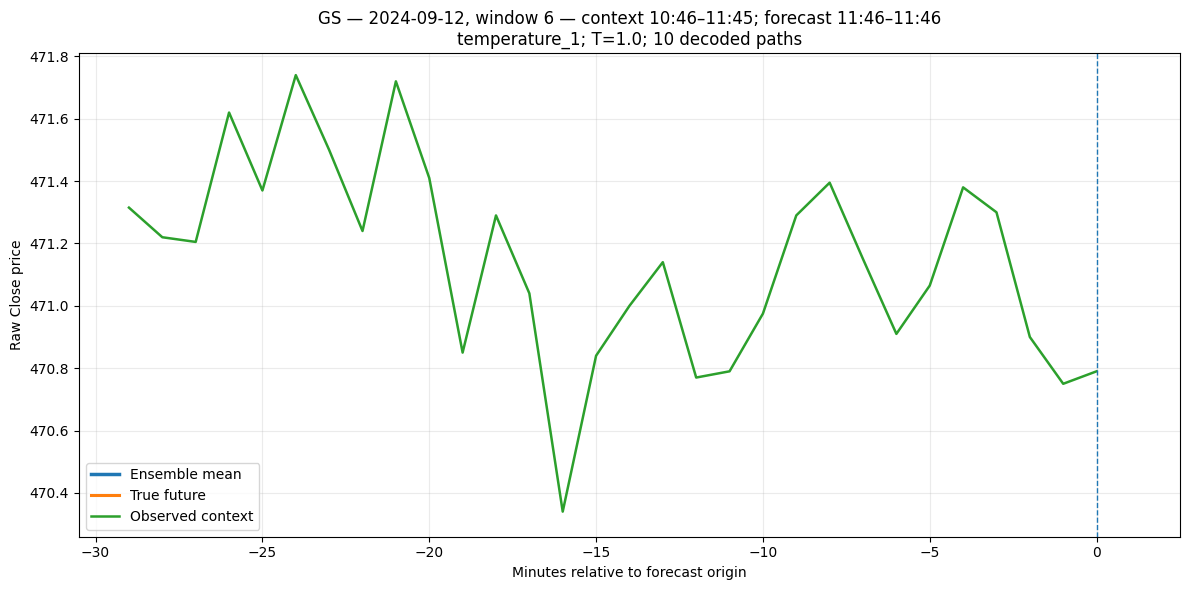

,Path 1,Path 2,Path 3,Path 4,Path 5,Path 6,Path 7,Path 8,Path 9,Path 10,Ensemble mean,True future
Horizon,,,,,,,,,,,,
1,470.603241,470.641022,471.132416,471.117096,470.484283,470.484283,470.645203,470.470215,470.663574,471.051636,470.729309,470.329987


In [198]:
# Inputs:
# - model: tokenized model folder with saved sampled-price-path artefact.
# - split: "train", "validation"/"val", or "test".
# - policy: None reads the saved selected temperature, or pass e.g. "temperature_1".
# - data_dir: canonical candle-data directory used to reconstruct dense truth.
# - asset/day/window: exact values or the explicit "random" sentinel.
# - context_points: number of observed Close points shown before the origin.
sampled_path_report = dge.analyse_sampled_path_example(
    "tokenized_basedygraph",
    split="val",
    policy=None,
    data_dir=dge.resolve_candle_data_root(),
    asset="random",
    day="random",
    window="random",
    random_seed=np.random.randint(0,1e6),
    context_points=30,
)

plt.show()

display(
    dge.style_numeric_table(
        sampled_path_report.horizons,
        caption="Ten sampled paths, ensemble mean and truth at the reported horizons",
        precision=6,
    )
)


## 11. Predictive intervals: coverage and sharpness

The sampled paths define an empirical distribution of cumulative log returns. For sampled path $s$, forecast horizon $h$, and last observed Close $P_0$:

$$
\widehat r_h^{(s)}=\log\left(\frac{\widehat P_h^{(s)}}{P_0}\right).
$$

For a requested central coverage level $c$, the lower and upper quantiles are:

$$
q_{\mathrm{low}}=q_{(1-c)/2},
$$

$$
q_{\mathrm{high}}=q_{1-(1-c)/2}.
$$

Empirical coverage is the fraction of realised returns inside that interval:

$$
\widehat{\operatorname{Coverage}}(c)
=\frac{1}{M}\sum_{m=1}^{M}
\mathbf{1}\left[q_{\mathrm{low},m}\leq r_m\leq q_{\mathrm{high},m}\right].
$$

The **coverage gap** is empirical minus nominal coverage. A negative gap means under-coverage: the predictive distribution is too narrow or biased. The `Below interval` and `Above interval` columns separate lower- and upper-tail misses; a large asymmetry indicates directional bias.

Sharpness is interval width:

$$
\operatorname{Width}(c)=q_{\mathrm{high}}-q_{\mathrm{low}}.
$$

The table multiplies width by 10,000 and reports log-return basis points. Narrow intervals are desirable only when coverage is adequate. A zero-width interval is perfectly sharp but useless if it misses nearly every realised return.

### Reading the calibration plot

Each point compares requested coverage on the x-axis with realised coverage on the y-axis. The dashed diagonal is perfect calibration.

- **Below the diagonal:** under-coverage; intervals are too narrow for the observed errors.
- **Above the diagonal:** over-coverage; intervals may be wider than necessary.
- **Closer to the diagonal:** better calibrated at that horizon and interval level.

With only 10 paths, quantiles and tail coverage have coarse finite-ensemble resolution. Always report coverage together with interval width.

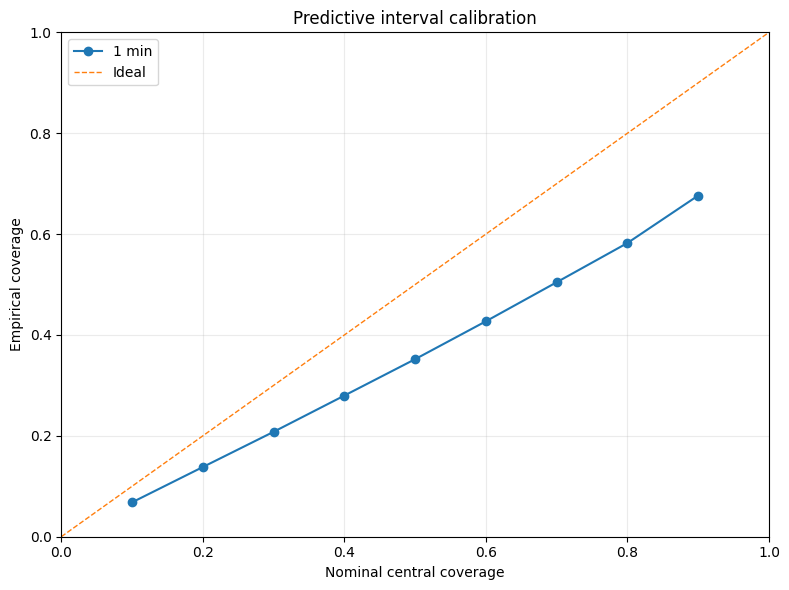

In [199]:
# Inputs:
# - model/split/policy: identify one saved finite-ensemble artefact.
# - nominal_coverages: central intervals to assess globally.
# - asset_coverage: interval used for the per-asset calibration table.
coverage_report = dge.make_predictive_coverage_report(
    "tokenized_basedygraph",
    split="validation",
    policy=None,
    nominal_coverages=(0.1,0.2,0.3,0.4,0.50,0.6,0.7,0.80,0.90),
    asset_coverage=0.80,
)

plt.show()

#display(
#    dge.style_numeric_table(
#        coverage_report.overall,
#        caption="Predictive interval coverage, tail misses and sharpness",
#        precision=5,
#    )
#)

asset_coverage_ranking = dge.make_asset_coverage_ranking(
    coverage_report.by_asset,
    horizon=60,
    top_n=20,
)

#display(
#    dge.style_numeric_table(
#        asset_coverage_ranking,
#        caption="Largest absolute asset-level central-80% coverage gaps at 60 minutes",
#        precision=5,
#    )
#)


## 12. CRPS and finite-ensemble truth ranks

### Empirical CRPS

The continuous ranked probability score rewards a predictive distribution that is close to truth while penalising unnecessary spread. For $S$ sampled returns $\widehat r^{(1)},\ldots,\widehat r^{(S)}$ and realised return $r$:

$$
\operatorname{CRPS}
=\frac{1}{S}\sum_{s=1}^{S}|\widehat r^{(s)}-r|
-\frac{1}{2S^2}\sum_{s=1}^{S}\sum_{s'=1}^{S}
|\widehat r^{(s)}-\widehat r^{(s')}|.
$$

The first term rewards paths close to truth. The second subtracts a dispersion term so that a wider distribution is not penalised twice. Lower CRPS is better. The table reports CRPS in log-return basis points, alongside ensemble-mean Log MAE, sample-median Log MAE and predictive standard deviation.

CRPS is useful for diagnosing why token sampling fails. A model can improve ensemble-mean MAE while still having poor CRPS if its individual paths are badly calibrated or excessively dispersed.

### Truth-rank histogram

For each forecast, sort the $S=10$ sampled returns and record how many are below the realised return. The rank ranges from 0 to 10:

- rank 0: truth is below every sampled path;
- rank 10: truth is above every sampled path;
- middle ranks: truth lies inside the sampled ensemble.

If the truth and paths were exchangeable, the 11 ranks would occur approximately equally often. A U-shaped histogram means the ensemble is too narrow; truth frequently falls outside both tails. A centre-heavy histogram means the ensemble is too wide. A left/right imbalance indicates systematic directional bias.

In [ ]:
# Input:
# - coverage_report: the object calculated in the preceding cell.
display(
    dge.style_numeric_table(
        coverage_report.probabilistic_scores,
        caption="CRPS, point summaries and predictive dispersion",
        precision=5,
    )
)

rank_figure, _ = dge.plot_sample_rank_histogram(
    coverage_report.rank_histogram,
)
plt.show()

#display(
#    dge.style_numeric_table(
#        coverage_report.rank_histogram,
#        caption="Truth rank among the ten sampled returns",
#        precision=5,
#    )
#)


## 13. Coarse-token predictive distribution

This optional GPU section reconstructs the saved token model and compares four different token-frequency views at one reported horizon:

1. **Mean model probability:** the average raw temperature-1 softmax probability assigned to each token before top-$p$ truncation.
2. **Argmax frequency:** how often each token is the highest-probability token.
3. **Training target frequency:** how common each token is in the training targets.
4. **Actual sampled frequency:** how often each token was realised across the retained Monte Carlo paths after the saved temperature and top-$p$ policy were applied.

These quantities answer different questions. A model may assign modest probability to many tokens but collapse under argmax. Conversely, temperature and top-p sampling may over-select a subset of the probability mass. Comparing the fourth bar with the first three helps explain whether failure arises from the learned distribution, the hard decision rule, or the sampling policy.

The `bars` argument can contain any subset of:

```text
"mean_probability"
"hard_prediction_frequency"
"training_target_frequency"
"sampled_frequency"
```

When `sampled_frequency` is requested, `horizon` must be one of the five retained evaluation horizons because the saved token artefact stores sampled IDs at those horizons rather than all 60 future positions.

In [ ]:
# Inputs:
# - model/split/policy: tokenized model and saved sampled policy.
# - asset: ticker, zero-based index, None to pool all assets, or "random".
# - horizon: one of 1, 5, 15, 30, 60 when sampled_frequency is plotted.
# - source: "best" or "last" checkpoint for the model probability/argmax pass.
# - max_windows: evenly spaced diagnostic subset; None uses the complete split.
# - bars: choose any subset of the four documented identifiers.
# - plot_top_n: number of token IDs shown; IDs are ranked by the largest
# - bars: options are:  "mean_probability", "hard_prediction_frequency", "training_target_frequency", "sampled_frequency"
 
token_distribution = dge.analyse_coarse_token_predictive_distribution(
    "tokenized_basedygraph",
    split="test",
    policy=None,
    asset=None,
    horizon=1,
    source="best",
    max_windows=64,
    batch_size=2,
    device=None,
    use_amp=None,
    plot_top_n=40,
    bars=(
        "mean_probability",
        "training_target_frequency",
        "sampled_frequency",
    ),
    random_seed=42,
)

plt.show()

display(
    dge.style_numeric_table(
        token_distribution["summary"],
        caption="Coarse-token distribution summary",
        precision=5,
    )
)
#display(
#    dge.style_numeric_table(
#        token_distribution["distribution_table"].head(50),
#        caption="Top 50 tokens by actual sampled frequency",
#        precision=5,
#    )
#)

## 14. Coarse-token top-$K$ accuracy

Exact top-1 token accuracy is stringent because several BSQ codes can decode to similar candles. Top-$K$ accuracy asks whether the true coarse token appears among the model's $K$ highest-probability candidates.

For horizon $h$:

$$
\operatorname{TopKAcc}_h
=\frac{1}{M}\sum_{m=1}^{M}
\mathbf{1}\left[y_{m,h}\in\operatorname{TopK}(p_{m,h})\right].
$$

The function also compares the model with a marginal baseline that always proposes the $K$ most frequent training tokens at that horizon. Positive excess accuracy means the model contains information beyond unconditional token popularity.

Top-$K$ accuracy is not a proper scoring rule and should not replace validation cross-entropy. It ignores how probability is distributed inside the top $K$. A true token ranked fifth with probability 0.20 and one ranked fifth with probability 0.002 receive the same top-5 score but have very different sampling behaviour.

In [200]:
# Inputs:
# - model/split: tokenized checkpoint and cache split to score.
# - asset: ticker/index, None to pool assets, or "random".
# - source: "best" or "last" checkpoint.
# - max_windows: evenly spaced diagnostic subset; None uses the complete split.
# - top_k_values: exact K values to report.
# - horizons: future minutes to score.
topk_table = dge.analyse_coarse_token_topk(
    "tokenized_basedygraph",
    split="test",
    asset=None,
    source="best",
    max_windows=64,
    batch_size=2,
    device=None,
    use_amp=None,
    top_k_values=(1, 2, 5, 10),
    horizons=(1, 5, 15, 30, 60),
    random_seed=42,
)

display(
    dge.style_numeric_table(
        topk_table,
        caption="Coarse-token top-K accuracy and excess over the training-frequency baseline",
        precision=4,
    )
)

KeyError: 'Config must contain models.dynamic_graph.'

## 15. Write-up checklist

Before using a Graph Hub result in the dissertation, record:

1. **Model provenance:** renamed folder, original run name, selected checkpoint epoch and saved inference policy.
2. **Data boundary:** train, validation or held-out test. Do not use test results to choose architecture, temperature or graph regularisation.
3. **Forecast metric space:** state explicitly whether a number is based on cumulative log returns or raw prices.
4. **Graph provenance:** split, date/window selection, graph component, layer, head and whether clustering was enabled.
5. **Graph aggregation:** distinguish an exact window from a day average, a fixed within-day window averaged across days, and a full-split average.
6. **Graph orientation:** rows are targets and columns are sources, $A[\text{target},\text{source}]$.
7. **Graph interpretation:** report entropy/effective neighbours and forecast ablations with adjacency plots; do not describe learned edges as causal market relationships.
8. **Token inference:** record temperature, top-p, sample count, seed and whether the point forecast is argmax or the mean of decoded sampled paths.
9. **Predictive intervals:** report empirical coverage together with width. Narrow intervals are not useful when they systematically miss truth.
10. **Finite ensemble:** state that coverage, CRPS and truth ranks are estimated from 10 Monte Carlo paths and therefore have limited tail resolution.
11. **Ablations:** verify from saved configs that graph type or loss weighting is the intended difference rather than one of several simultaneous changes.